## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

## Load Dataset

In [3]:
file_path = '/content/drive/MyDrive/Colab Notebooks/data mining for cybersecurity - data/Live GPS Spoofing and Jamming/UAV_Attack_Dataset_SUBSET.csv'
data = pd.read_csv(file_path)

In [4]:
selected_features = ['control[0]',
    'control[1]',
    'control[2]',
    'control[3]',
    'vel_m_s',
    'vel_n_m_s',
   'vel_e_m_s',
   'vel_d_m_s',
   'gps_hvel[0]_var',
  'gps_hvel[0]_inn',
  'gps_hvel[1]_inn',
  'gps_vvel_inn',
  'gps_hpos[0]_inn',
  'gps_hpos[1]_inn']
data_subset = data[selected_features]

## Target Seperation & Class Encoding

In [5]:
X = data_subset
y = data['class']

In [6]:
class_mapping = {
    'benign flight': 0,
    'gps jamming': 1,
    'gps spoofing': 2
    }

In [7]:
y = y.map(class_mapping)

### FEATURE ENGINEERING

In [8]:
# FEATURE ENGINEERING

print("FEATURE ENGINEERING")

# Control Signal Statistics
control_columns = [c for c in X.columns if 'control' in c]
if len(control_columns) > 1:
    X['control_std'] = X[control_columns].std(axis=1)

# GPS Variance Sum
variance_columns = [c for c in X.columns if '_var' in c]
if len(variance_columns) > 1:
    X['gps_var_sum'] = X[variance_columns].sum(axis=1)

# GPS Innovation Sum
innovation_columns = [c for c in X.columns if '_inn' in c]
if len(innovation_columns) > 1:
    X['gps_inn_sum'] = X[innovation_columns].abs().sum(axis=1)
    print("Created: gps_inn_sum (Sum of Absolute Innovations)")

print(f"\n Total features after engineering: {X.shape[1]}")

FEATURE ENGINEERING
Created: gps_inn_sum (Sum of Absolute Innovations)

 Total features after engineering: 16


/tmp/ipython-input-987/2959810596.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['control_std'] = X[control_columns].std(axis=1)
/tmp/ipython-input-987/2959810596.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['gps_inn_sum'] = X[innovation_columns].abs().sum(axis=1)


## Train-Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Scaling

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Logistic Regression Parameter Grid

In [12]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'newton-cg'],
    'max_iter': [1000, 2000]
}

### Defining the Model

In [13]:
log_reg = LogisticRegression(multi_class='multinomial', class_weight='balanced', random_state=42)

### Initialize Grid Search

In [16]:
print("Searching for best parameters using Grid Search...")

Searching for best parameters using Grid Search...


In [14]:
grid_search = GridSearchCV(estimator=log_reg, param_grid=param_grid, cv=5, verbose=1, n_jobs=-1)

In [17]:
# Start Training

In [15]:
grid_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


GridSearchCV(cv=5,
             estimator=LogisticRegression(class_weight='balanced',
                                          multi_class='multinomial',
                                          random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100], 'max_iter': [1000, 2000],
                         'solver': ['lbfgs', 'newton-cg']},
             verbose=1)

In [18]:
print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")


Best Parameters: {'C': 0.01, 'max_iter': 1000, 'solver': 'lbfgs'}
Best CV Score: 0.6011


In [19]:
# Prediction on Test Set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_scaled)

In [20]:
# Class Labels
class_labels = ["benign flight", "gps jamming", "gps spoofing"]

print("\n--- Logistic Regression Results ---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=class_labels))


--- Logistic Regression Results ---
Accuracy: 0.6033057851239669

Classification Report:
                precision    recall  f1-score   support

benign flight       0.65      0.70      0.67       493
  gps jamming       0.55      0.34      0.42       444
 gps spoofing       0.58      0.85      0.69       273

     accuracy                           0.60      1210
    macro avg       0.59      0.63      0.60      1210
 weighted avg       0.60      0.60      0.58      1210



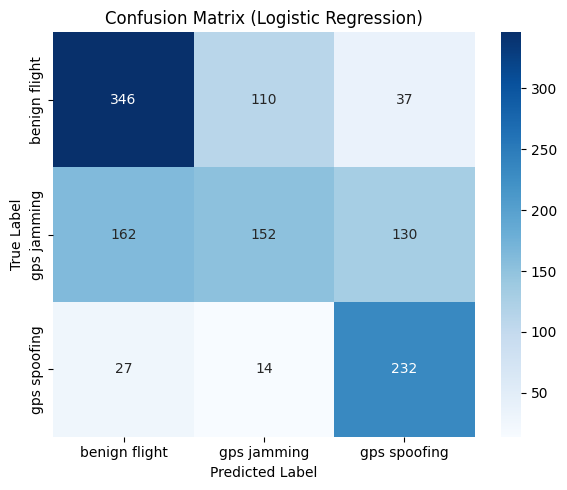

In [21]:
# Visualize Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Logistic Regression)")
plt.tight_layout()
plt.show()